# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import os

print('Current Working Directory:')
print(os.getcwd())

Current Working Directory:
/Users/subhankarbiswas/glassdoor-nlp-project/notebooks


# Load Data

In [3]:
file_path = '../data/processed/cleaned_jobs.csv'

if os.path.exists(file_path):
    print('Dataset found.')
    df = pd.read_csv(file_path)
    print(df.head())
    print('\nDataset Shape:', df.shape)
else:
    print('Dataset not found.')
    
    print(df.columns)

Dataset found.
               company                       job_title  company_rating  \
0                  ABB             Junior Data Analyst             4.0   
1              Philips          Data Scientist - AI/ML             4.0   
2                 HSBC              Data Science GSC’s             3.9   
3    Facctum Solutions                    Data Analyst             NaN   
4  JPMorgan Chase & Co  Data and Analytics - Associate             4.0   

                                     job_description   location  \
0  Junior Data Analyst\nTake your next career ste...  Bengaluru   
1  Job Title\nData Scientist - AI/ML\nJob Descrip...  Bengaluru   
2  Job description\nGraduate/ Post-graduate degre...  Bengaluru   
3  Job Description\nExperience: 0 - 2 years in da...  Karnataka   
4  JOB DESCRIPTION\n\nYou are a strategic thinker...      India   

  salary_avg_estimate salary_estimate_payperiod       company_size  \
0           ₹3,25,236                /yr (est.)   10000+ Employees 

# Combine Text

In [4]:
import re
from nltk.tokenize import word_tokenize

def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\\S+', ' ', text)

    # Keep alphabets only
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\\s+', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Keep words longer than 2 chars
    cleaned_tokens = [
        word for word in tokens
        if len(word) > 2
    ]

    return " ".join(cleaned_tokens)

In [5]:
df['cleaned_text'] = df['job_description'].apply(clean_text)

In [6]:
# Remove NaN rows
df = df.dropna(subset=['cleaned_text'])

# Remove empty rows
df = df[df['cleaned_text'].astype(str).str.strip() != ""]

# Combine text
all_text = " ".join(df['cleaned_text'].astype(str))

print("Total text length:", len(all_text))

print("\nFirst 1000 characters:\n")
print(all_text[:1000])

Total text length: 2052479

First 1000 characters:

junior data analyst take your next career step abb with global team that energizing the transformation society and industry achieve more productive sustainable future abb have the clear goal driving diversity and inclusion across all dimensions gender lgbtq abilities ethnicity and generations together are embarking journey where each and every one individually and collectively welcomes and celebrates individual differences you will working junior data analyst and will part process automation business area for measurement and analytics division based bangalore india this role you will reporting coe data management and analytics manager and will responsible for performing data analytics activities and developing analytical solutions enable business strategy development for existing and potential products systems services your responsibilities using data systems help gather measure organize and analyze data providing sound market and com

# Top Keywords

In [7]:
words = all_text.split()
word_freq = Counter(words)
most_common = word_freq.most_common(20)
words_list = [word for word, freq in most_common]
freq_list = [freq for word, freq in most_common]
print(most_common)

[('and', 19015), ('data', 8443), ('the', 7561), ('with', 4629), ('for', 3500), ('experience', 2798), ('our', 2455), ('work', 1979), ('you', 1966), ('business', 1932), ('skills', 1672), ('are', 1650), ('team', 1450), ('that', 1374), ('will', 1323), ('job', 1052), ('analysis', 982), ('from', 972), ('knowledge', 963), ('management', 921)]


# Plot Keywords

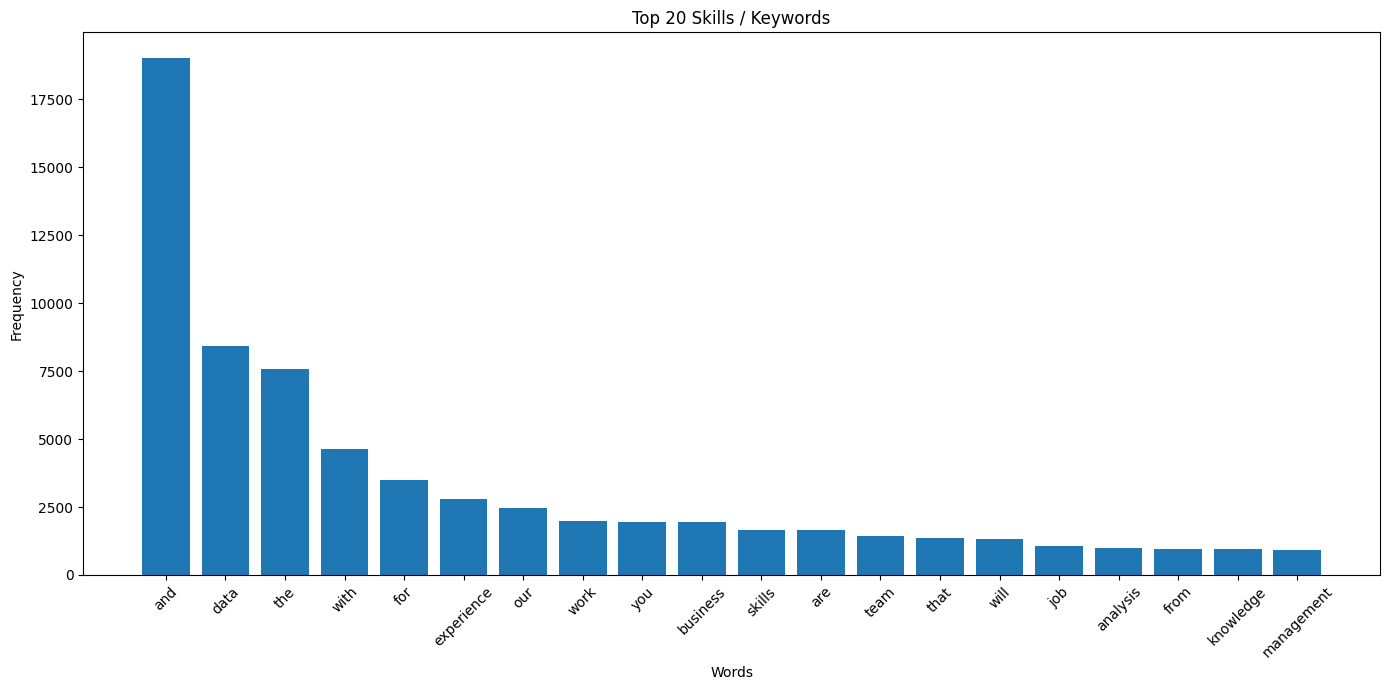

In [8]:
plt.figure(figsize=(14,7))
plt.bar(words_list, freq_list)
plt.xticks(rotation=45)
plt.title('Top 20 Skills / Keywords')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/figures/top_keywords.png')
plt.show()

# Word Cloud

In [9]:

print("Number of rows:", len(df))

print("\nNull cleaned_text values:")
print(df['cleaned_text'].isnull().sum())

print("\nEmpty cleaned_text rows:")
print((df['cleaned_text'].astype(str).str.strip() == '').sum())

print("\nSample cleaned_text values:")
print(df['cleaned_text'].head(10))

print("\nAverage text length:")
print(df['cleaned_text'].astype(str).str.len().mean())

Number of rows: 883

Null cleaned_text values:
0

Empty cleaned_text rows:
0

Sample cleaned_text values:
0    junior data analyst take your next career step...
1    job title data scientist job description job t...
2    job description graduate post graduate degree ...
3    job description experience years data operatio...
4    job description you are strategic thinker pass...
5    job code data scientist fresher location banga...
6    highlights experience freshers joining date im...
7    job code data scientist fresher location hyder...
8    the data science team oracle analytics works d...
9    about phonepe group phonepe india leading digi...
Name: cleaned_text, dtype: str

Average text length:
2323.4394110985277


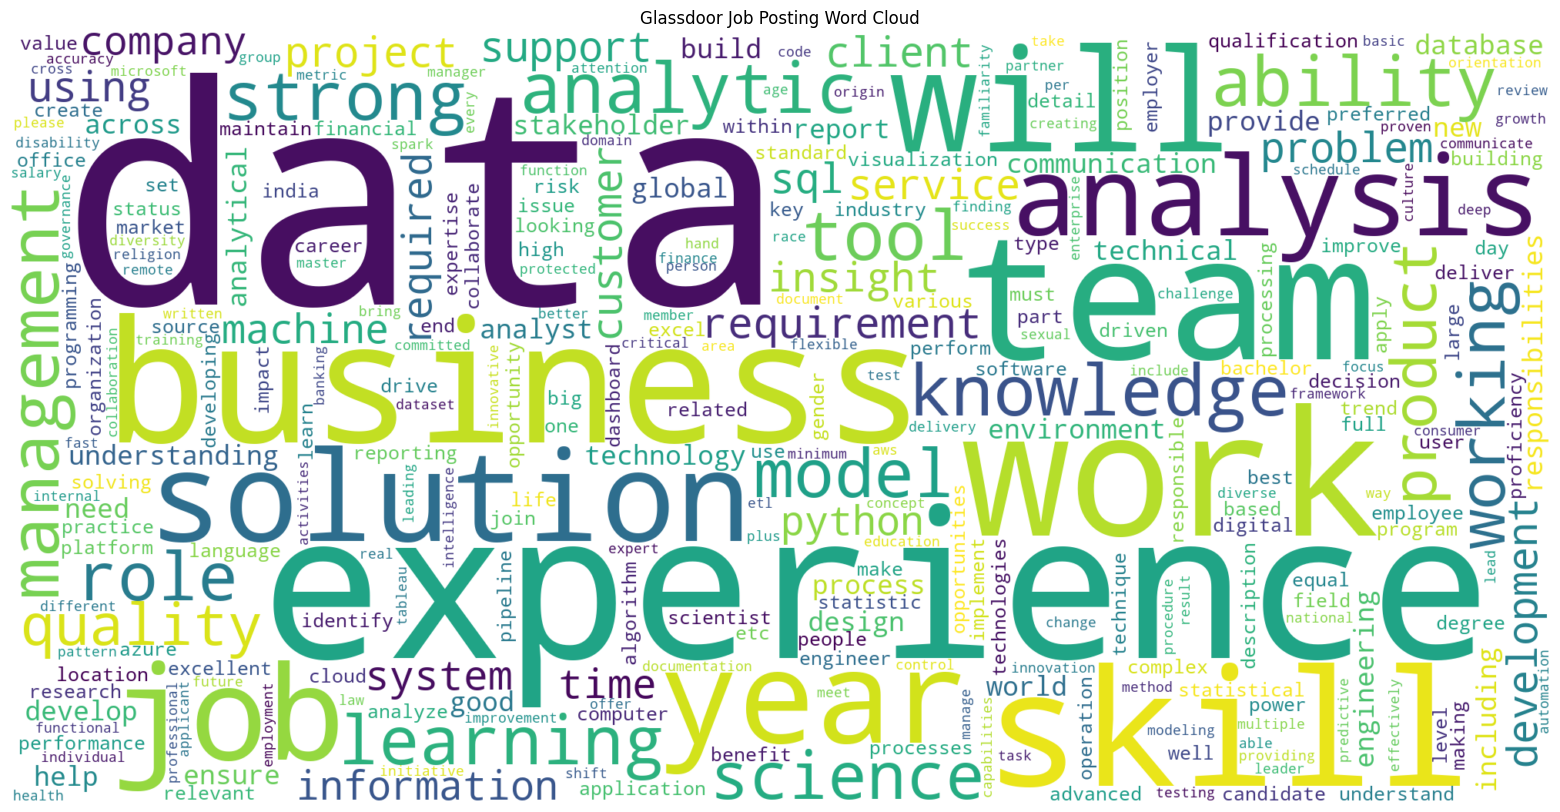

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Check text length
if len(all_text.split()) > 20:

    wordcloud = WordCloud(
        width=2000,
        height=1000,
        background_color='white',
        max_words=300,
        collocations=False
    ).generate(all_text)

    plt.figure(figsize=(20,10))

    plt.imshow(wordcloud, interpolation='bilinear')

    plt.axis('off')

    plt.title("Glassdoor Job Posting Word Cloud")
    
    plt.savefig('../outputs/figures/wordcloud.png')

    plt.show()

else:
    print("Not enough valid text for WordCloud.")

# Salary Distribution

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Dataset path
file_path = "../data/processed/cleaned_jobs.csv"

# Load dataset
if os.path.exists(file_path):

    print("Dataset found.")

    df = pd.read_csv(file_path)

    print(df.head())

    print("\nColumns:")
    print(df.columns)

else:
    print("Dataset not found.")

Dataset found.
               company                       job_title  company_rating  \
0                  ABB             Junior Data Analyst             4.0   
1              Philips          Data Scientist - AI/ML             4.0   
2                 HSBC              Data Science GSC’s             3.9   
3    Facctum Solutions                    Data Analyst             NaN   
4  JPMorgan Chase & Co  Data and Analytics - Associate             4.0   

                                     job_description   location  \
0  Junior Data Analyst\nTake your next career ste...  Bengaluru   
1  Job Title\nData Scientist - AI/ML\nJob Descrip...  Bengaluru   
2  Job description\nGraduate/ Post-graduate degre...  Bengaluru   
3  Job Description\nExperience: 0 - 2 years in da...  Karnataka   
4  JOB DESCRIPTION\n\nYou are a strategic thinker...      India   

  salary_avg_estimate salary_estimate_payperiod       company_size  \
0           ₹3,25,236                /yr (est.)   10000+ Employees 

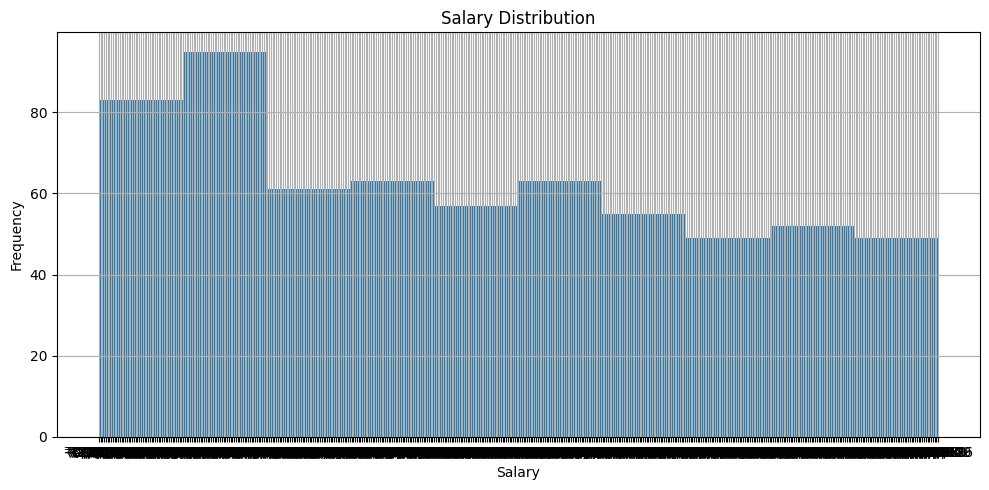

In [12]:
# Salary Distribution Plot

if 'salary_avg_estimate' in df.columns:

    # Remove missing values
    salary_data = df['salary_avg_estimate'].dropna()

    # Plot
    plt.figure(figsize=(10,5))

    salary_data.hist()

    plt.title("Salary Distribution")

    plt.xlabel("Salary")

    plt.ylabel("Frequency")

    plt.tight_layout()

    # Save figure
    plt.savefig("../outputs/figures/salary_distribution.png")

    plt.show()

else:
    print("salary_avg_estimate column not found.")

# Imports

In [13]:
from collections import Counter
import pandas as pd

# Generate Word Frequencies

In [14]:
# Combine all cleaned text
all_text = " ".join(
    df['cleaned_text'].astype(str)
)

# Tokenize
words = all_text.split()

# Count frequency
word_freq = Counter(words)

# Top 100 words
top_words = word_freq.most_common(100)

# Convert to dataframe
keyword_df = pd.DataFrame(
    top_words,
    columns=['Keyword', 'Frequency']
)

# Display
print(keyword_df.head())

  Keyword  Frequency
0     and      19015
1    data       8443
2     the       7561
3    with       4629
4     for       3500


# Save CSV

In [15]:
keyword_df.to_csv(
    "../outputs/tables/keyword_frequency.csv",
    index=False
)

print("keyword_frequency.csv generated.")

keyword_frequency.csv generated.
